<a href="https://colab.research.google.com/github/GampichXD/Computer-Vision---Indonesia-AI--Making-Own-Material-/blob/main/Day%205%20-%20Fundamental%20Deep%20Learning/notebooks/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!nvidia-smi


Tue Jun 16 15:11:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#Install Libraries
!pip install tensorflow matplotlib seaborn numpy scikit-learn

In [5]:
#Import Library
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.utils import to_categorical

print(f"Tensorflow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

Tensorflow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
#Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Dataset info:")
print(f"Train shape: {X_train.shape}") # (60000, 28, 28)
print(f"Test shape: {X_test.shape}") # (10000, 28, 28)
print(f"Classes: {np.unique(y_train)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset info:
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)
Classes: [0 1 2 3 4 5 6 7 8 9]


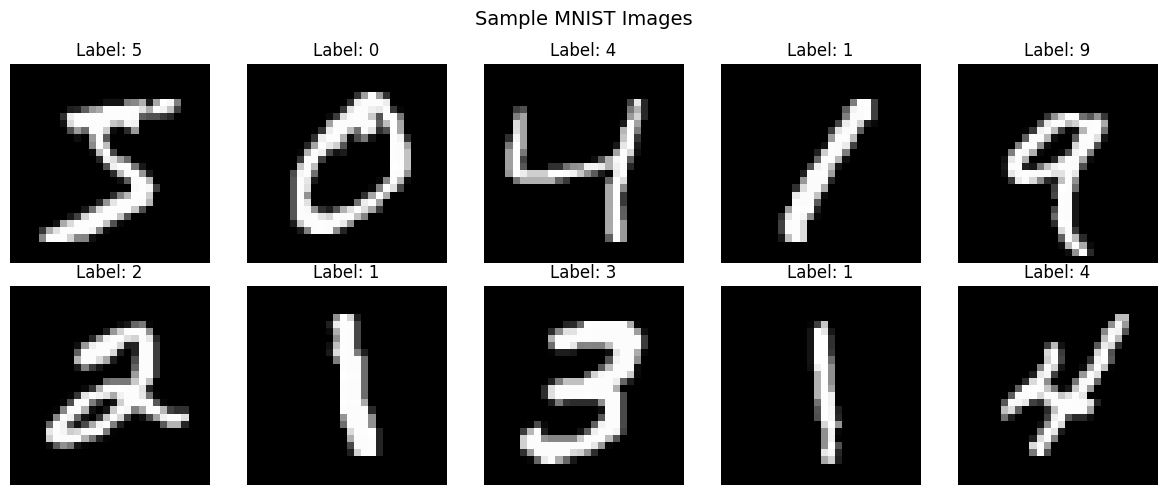

In [7]:
from numpy.random.mtrand import f
#Visualisasi sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
  ax.imshow(X_train[i], cmap='gray')
  ax.set_title(f"Label: {y_train[i]}")
  ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

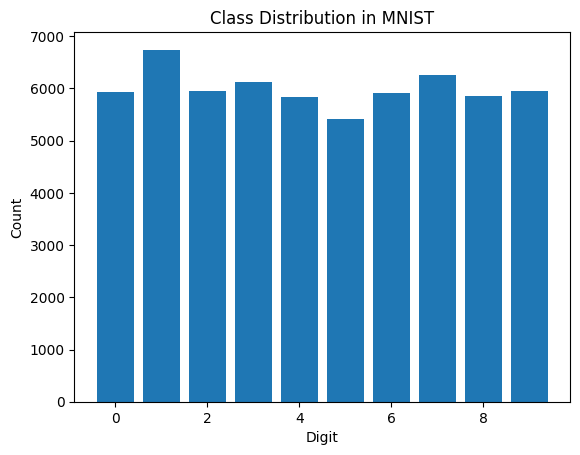

In [8]:
#Check class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.bar(unique, counts)
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Class Distribution in MNIST')
plt.show()

In [9]:
#Preprocessing untuk Deep Learning
#Normalisasi pixel values (0-255 -> 0-1)
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

#Reshape untuk input layer (28,28,1) untuk CNN
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

#Untuk Fully Connected Network, flatten jadi vektor 784
X_train_fcn = X_train_norm.reshape(-1, 784)
X_test_fcn = X_test_norm.reshape(-1, 784)

#One-hot encoding untuk target (10 classes)
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print(f"After processing:")
print(f"FCN input shape: {X_train_fcn.shape}")
print(f"CNN input shape: {X_train_cnn.shape}")
print(f"Target shape: {y_train_cat.shape}")

After processing:
FCN input shape: (60000, 784)
CNN input shape: (60000, 28, 28, 1)
Target shape: (60000, 10)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fully Connected Network (FCN) Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

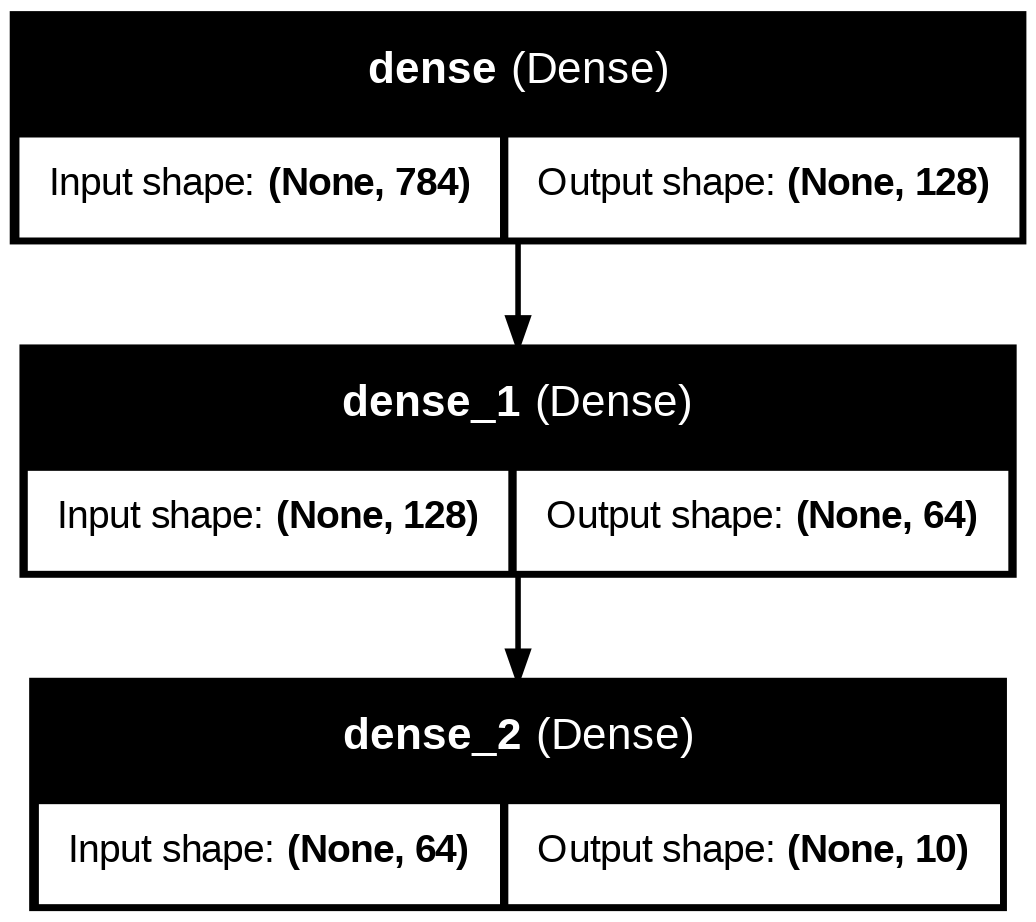

In [10]:
from sklearn import metrics
#Build fully connected network (FCN)
#Build model
fcn_model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

#Compile model
fcn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Model summary
print("Fully Connected Network (FCN) Summary:")
fcn_model.summary()

#Visualisasi model
from tensorflow.keras.utils import plot_model
plot_model(fcn_model, show_shapes= True, show_layer_names=True)

# Input: 784 neuron (28x28 piksel di-flatten)

# Hidden 1: 128 neuron dengan ReLU

# Hidden 2: 64 neuron dengan ReLU

# Output: 10 neuron dengan Softmax (probabilitas 10 digit)

# Total parameter: ~100,000

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9968 - loss: 0.0093 - val_accuracy: 0.9681 - val_loss: 0.1887
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9964 - loss: 0.0100 - val_accuracy: 0.9688 - val_loss: 0.2071
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9961 - loss: 0.0118 - val_accuracy: 0.9710 - val_loss: 0.1784
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9977 - loss: 0.0062 - val_accuracy: 0.9741 - val_loss: 0.1775
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9970 - loss: 0.0093 - val_accuracy: 0.9750 - val_loss: 0.1667
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9975 - loss: 0.0087 - val_accuracy: 0.9759 - val_loss: 0.1754
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9976 - loss: 0.0080 - val_accuracy: 0.9753 - val_loss: 0.1741
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9977 - loss: 0.0072 - 

<function matplotlib.pyplot.show(close=None, block=None)>

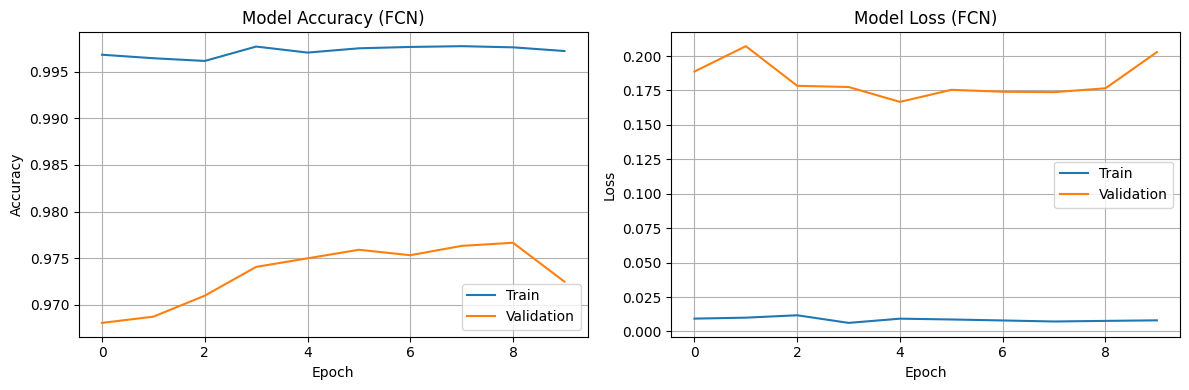

In [13]:
from IPython.core.pylabtools import figsize
#Train Model
history_fcn = fcn_model.fit(
    X_train_fcn, y_train_cat,
    batch_size = 32,
    epochs = 10,
    validation_split = 0.2,
    verbose = 1
)

#Evaluate
test_lost, test_acc = fcn_model.evaluate(X_test_fcn, y_test_cat, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

#Plot training history
fig, axes = plt.subplots(1, 2, figsize= (12, 4))

axes[0].plot(history_fcn.history['accuracy'], label='Train')
axes[0].plot(history_fcn.history['val_accuracy'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy (FCN)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_fcn.history['loss'], label='Train')
axes[1].plot(history_fcn.history['val_loss'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss (FCN)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show

In [14]:
#Convolutional Neural Network
cnn_model = models.Sequential([
    #First convolutional block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    #Second convolutional block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    #Third convolutional block
    layers.Conv2D(64, (3,3), activation='relu'),

    #Fully connected layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

#Compile
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Architecture")
cnn_model.summary()

#Count parameters
total_params = cnn_model.count_params()
print(f"\nTotal parameters: {total_params}")

# Interpretasi CNN:

# Conv2D(32,3,3): 32 filter ukuran 3x3, belajar fitur seperti tepi

# MaxPooling(2,2): Reduce ukuran 2x, pertahankan fitur penting

# Flatten: Ubah feature map 2D menjadi vektor 1D

# Keuntungan: Parameter sharing → lebih sedikit parameter daripada FCN

CNN Architecture


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 93322


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9495 - loss: 0.1648 - val_accuracy: 0.9809 - val_loss: 0.0659
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9840 - loss: 0.0519 - val_accuracy: 0.9850 - val_loss: 0.0482
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9891 - loss: 0.0357 - val_accuracy: 0.9867 - val_loss: 0.0498
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9902 - loss: 0.0300 - val_accuracy: 0.9871 - val_loss: 0.0451
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9930 - loss: 0.0223 - val_accuracy: 0.9896 - val_loss: 0.0444
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9939 - loss: 0.0186 - val_accuracy: 0.9899 - val_loss: 0.0389
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9949 - loss: 0.0151 - val_accuracy: 0.9883 - val_loss: 0.0452
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9959 - loss: 0.0124 -

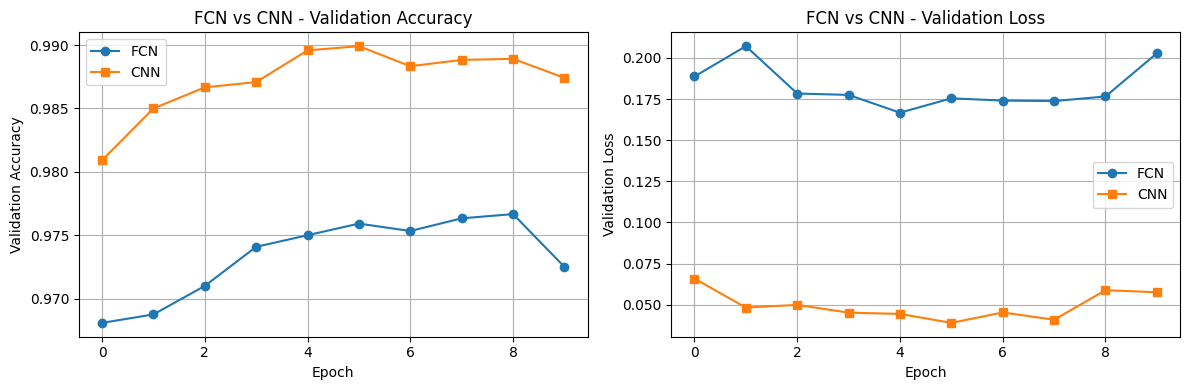

In [15]:
# Train CNN
history_cnn = cnn_model.fit(
    X_train_cnn, y_train_cat,
    batch_size=32,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

# Evaluate
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"\nCNN Test Accuracy: {test_acc_cnn:.4f}")
print(f"FCN Test Accuracy: {test_acc:.4f}")
print(f"Improvement: {(test_acc_cnn - test_acc)*100:.2f}%")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(history_fcn.history['val_accuracy'], label='FCN', marker='o')
axes[0].plot(history_cnn.history['val_accuracy'], label='CNN', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('FCN vs CNN - Validation Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_fcn.history['val_loss'], label='FCN', marker='o')
axes[1].plot(history_cnn.history['val_loss'], label='CNN', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('FCN vs CNN - Validation Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

First layer weights shape: (3, 3, 1, 32)


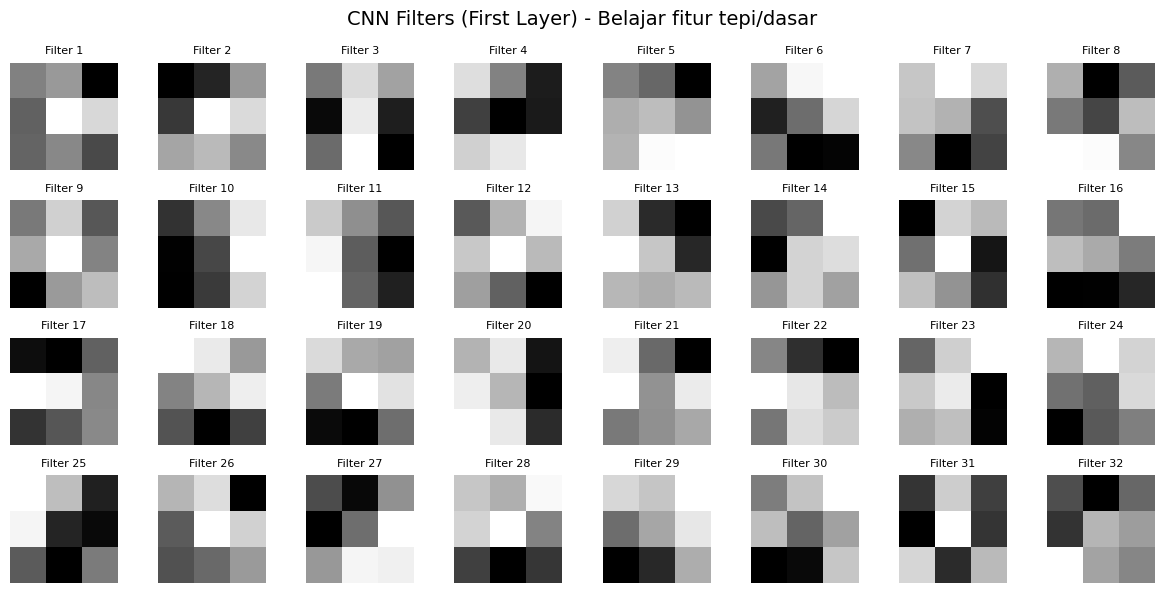

In [18]:
#Visualize CNN filters & feature maps
#Get first layer weights
first_layer_weights = cnn_model.layers[0].get_weights()[0]
print(f"First layer weights shape: {first_layer_weights.shape}")

#Visualize filters (32 filters, 3x3)
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
  if i < 32:
    filter_img = first_layer_weights[:,:,0,i]
    ax.imshow(filter_img, cmap='gray')
    ax.set_title(f"Filter {i+1}", fontsize=8)
  ax.axis('off')
plt.suptitle('CNN Filters (First Layer) - Belajar fitur tepi/dasar', fontsize=14)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


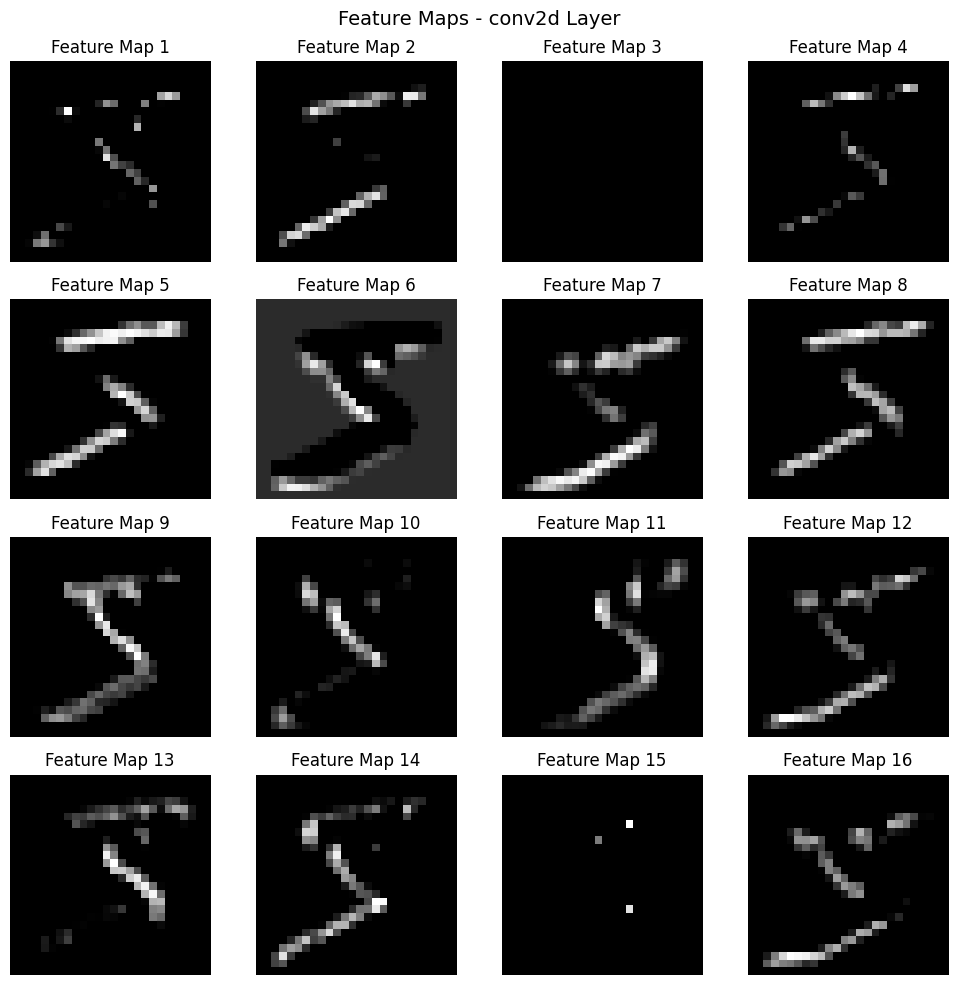

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step


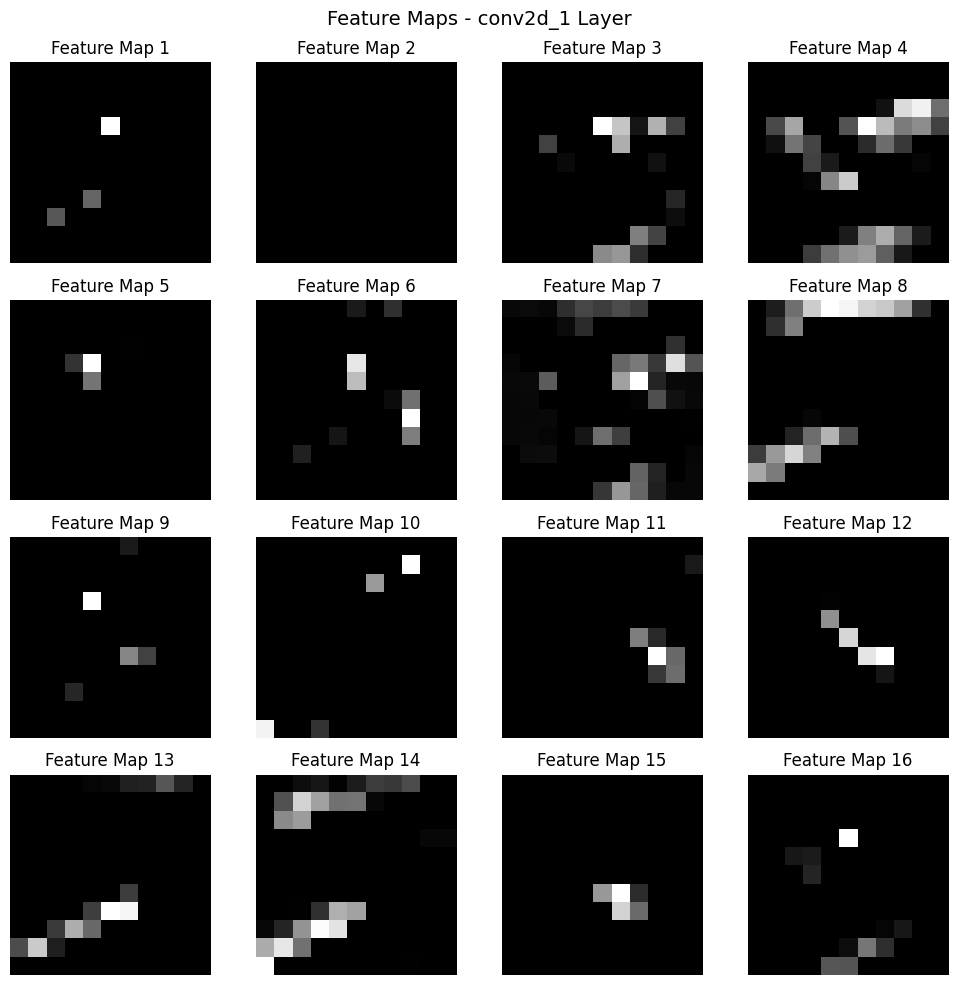

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

#Get intermediate layer outputs
def visualize_feature_maps(model, image, layer_name):
    # Create model that outputs specific layer
    layer_output = model.get_layer(layer_name).output
    intermediate_model = tf.keras.Model(inputs=model.inputs[0], outputs=layer_output)

    # Get feature maps
    feature_maps = intermediate_model.predict(image[np.newaxis, ...])

    # Plot first 16 feature maps
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        if i < 16:
            ax.imshow(feature_maps[0, :, :, i], cmap='gray')
            ax.set_title(f'Feature Map {i+1}')
        ax.axis('off')
    plt.suptitle(f'Feature Maps - {layer_name} Layer', fontsize=14)
    plt.tight_layout()
    plt.show()

#Visualize feature maps for a sample image
sample_idx = 0
visualize_feature_maps(cnn_model, X_train_cnn[sample_idx], 'conv2d')
visualize_feature_maps(cnn_model, X_train_cnn[sample_idx], 'conv2d_1')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


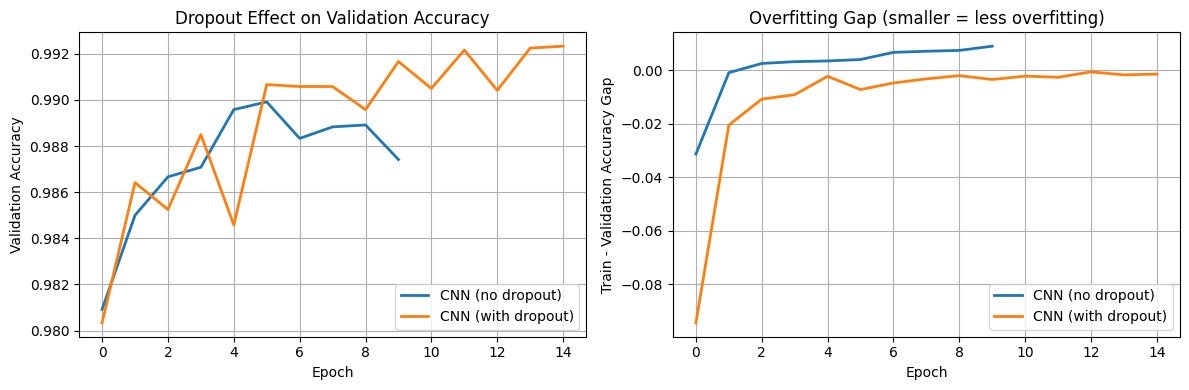

CNN without Dropout - Test Acc: 0.9886
CNN with Dropout - Test Acc: 0.9925


In [22]:
#Regularization Techniques
#Dropout untuk cegah overfitting
# Model dengan Dropout
cnn_with_dropout = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),  # 25% neuron dimatikan

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),  # Dropout lebih besar di dense layer
    layers.Dense(10, activation='softmax')
])

cnn_with_dropout.compile(optimizer='adam',
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

# Train dengan lebih banyak epoch untuk lihat efek
history_dropout = cnn_with_dropout.fit(
    X_train_cnn, y_train_cat,
    batch_size=32,
    epochs=15,
    validation_split=0.2,
    verbose=0
)

# Compare overfitting
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['val_accuracy'], label='CNN (no dropout)', linewidth=2)
plt.plot(history_dropout.history['val_accuracy'], label='CNN (with dropout)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Dropout Effect on Validation Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
train_acc_cnn = history_cnn.history['accuracy']
val_acc_cnn = history_cnn.history['val_accuracy']
train_acc_drop = history_dropout.history['accuracy']
val_acc_drop = history_dropout.history['val_accuracy']

overfit_gap_cnn = [t - v for t, v in zip(train_acc_cnn, val_acc_cnn)]
overfit_gap_drop = [t - v for t, v in zip(train_acc_drop, val_acc_drop)]

plt.plot(overfit_gap_cnn, label='CNN (no dropout)', linewidth=2)
plt.plot(overfit_gap_drop, label='CNN (with dropout)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Train - Validation Accuracy Gap')
plt.title('Overfitting Gap (smaller = less overfitting)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"CNN without Dropout - Test Acc: {test_acc_cnn:.4f}")
print(f"CNN with Dropout - Test Acc: {cnn_with_dropout.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]:.4f}")

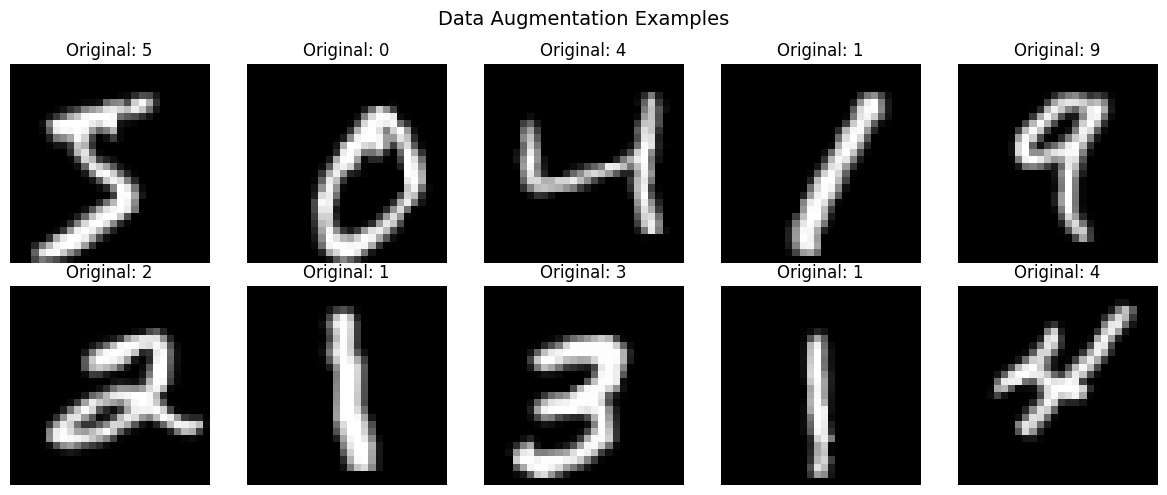

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN with Data Augmentation - Test Acc: 0.9935


In [23]:
#Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create data augmentation generator
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Visualize augmented images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    augmented = datagen.random_transform(X_train_cnn[i])
    ax.imshow(augmented.squeeze(), cmap='gray')
    ax.set_title(f'Original: {y_train[i]}')
    ax.axis('off')
plt.suptitle('Data Augmentation Examples', fontsize=14)
plt.tight_layout()
plt.show()

# Train model with augmentation
cnn_augmented = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_augmented.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train with augmented data
history_augmented = cnn_augmented.fit(
    datagen.flow(X_train_cnn, y_train_cat, batch_size=32),
    epochs=10,
    validation_data=(X_test_cnn, y_test_cat),
    verbose=0
)

print(f"CNN with Data Augmentation - Test Acc: {history_augmented.history['val_accuracy'][-1]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


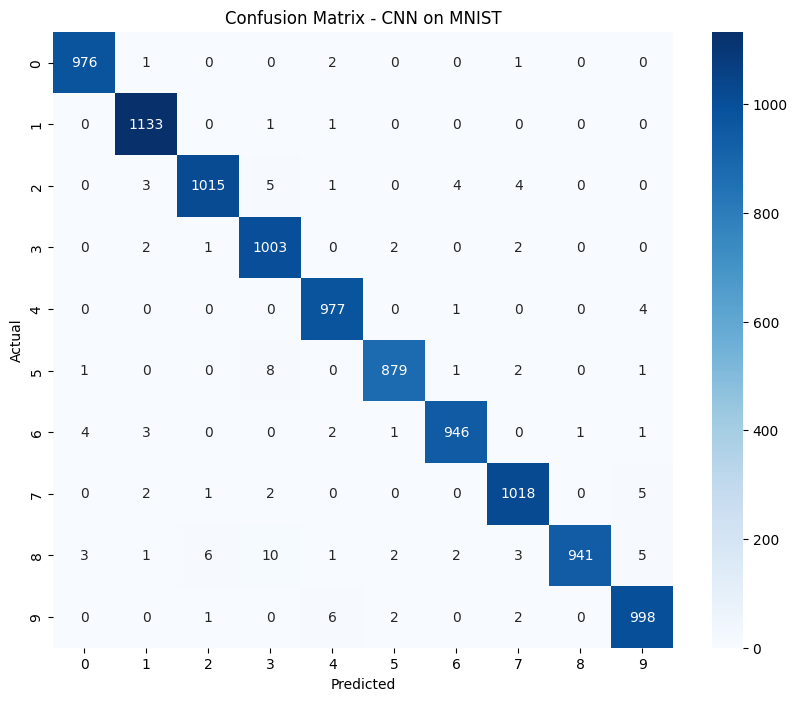

Total misclassified: 114 out of 10000 (1.14%)


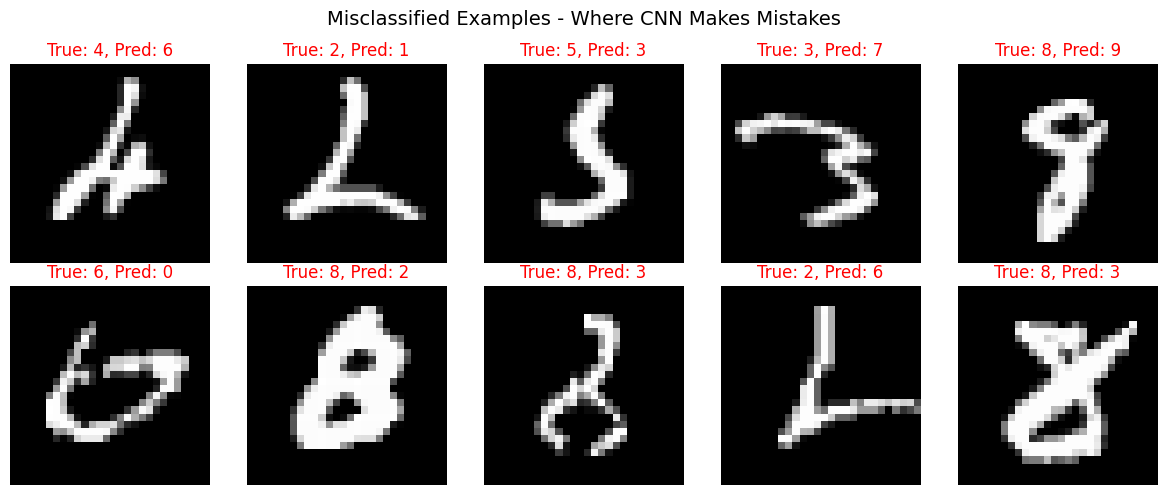

In [24]:
#Confusion Matrix & Error Analysis
# Make predictions
y_pred = cnn_model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - CNN on MNIST')
plt.show()

# Find misclassified examples
misclassified_idx = np.where(y_pred_classes != y_test)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_test)} ({len(misclassified_idx)/len(y_test)*100:.2f}%)")

# Show some misclassified examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if i < len(misclassified_idx):
        idx = misclassified_idx[i]
        ax.imshow(X_test[idx], cmap='gray')
        ax.set_title(f'True: {y_test[idx]}, Pred: {y_pred_classes[idx]}', color='red')
    ax.axis('off')
plt.suptitle('Misclassified Examples - Where CNN Makes Mistakes', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
#Transfer Learning
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load Fashion-MNIST (lebih sulit dari MNIST)
(X_fashion, y_fashion), (X_fashion_test, y_fashion_test) = fashion_mnist.load_data()

# Preprocess untuk MobileNet (butuh 3 channel dan ukuran 32x32)
X_fashion_resized = np.stack([X_fashion]*3, axis=-1)
X_fashion_resized = tf.image.resize(X_fashion_resized, (32, 32)).numpy()
X_fashion_resized = preprocess_input(X_fashion_resized)

# Load pre-trained model (tanpa top layer)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = False  # Freeze base model

# Add custom classifier
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

transfer_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

transfer_model.summary()

# Train (hanya classifier head yang belajar)
history_transfer = transfer_model.fit(
    X_fashion_resized[:10000], y_fashion[:10000],
    batch_size=32,
    epochs=5,
    validation_data=(X_fashion_resized[10000:12000], y_fashion[10000:12000]),
    verbose=1
)

print("Transfer Learning mampu belajar dengan data lebih sedikit karena sudah punya feature extractor dari ImageNet!")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/tmp/ipykernel_1684/146789307.py:14: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32,32,3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 66ms/step - accuracy: 0.3225 - loss: 1.9068 - val_accuracy: 0.3910 - val_loss: 1.7091
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3836 - loss: 1.6818 - val_accuracy: 0.3975 - val_loss: 1.6264
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4058 - loss: 1.6265 - val_accuracy: 0.4100 - val_loss: 1.6027
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4127 - loss: 1.5918 - val_accuracy: 0.4255 - val_loss: 1.5823
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4197 - loss: 1.5760 - val_accuracy: 0.4225 - val_loss: 1.5774
Transfer Learning mampu belajar dengan data lebih sedikit karena sudah punya feature extractor dari ImageNet!


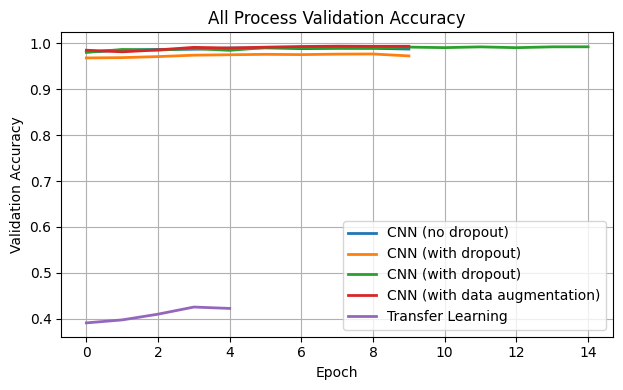

In [28]:
# Compare all history
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['val_accuracy'], label='CNN (no dropout)', linewidth=2)
plt.plot(history_fcn.history['val_accuracy'], label='CNN (with dropout)', linewidth=2)
plt.plot(history_dropout.history['val_accuracy'], label='CNN (with dropout)', linewidth=2)
plt.plot(history_augmented.history['val_accuracy'], label='CNN (with data augmentation)', linewidth=2)
plt.plot(history_transfer.history['val_accuracy'], label='Transfer Learning', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('All Process Validation Accuracy')
plt.legend()
plt.grid(True)

# plt.subplot(1,2,2)
# train_acc_cnn = history_cnn.history['accuracy']
# val_acc_cnn = history_cnn.history['val_accuracy']
# train_acc_drop = history_dropout.history['accuracy']
# val_acc_drop = history_dropout.history['val_accuracy']

# overfit_gap_cnn = [t - v for t, v in zip(train_acc_cnn, val_acc_cnn)]
# overfit_gap_drop = [t - v for t, v in zip(train_acc_drop, val_acc_drop)]

# plt.plot(overfit_gap_cnn, label='CNN (no dropout)', linewidth=2)
# plt.plot(overfit_gap_drop, label='CNN (with dropout)', linewidth=2)
# plt.xlabel('Epoch')
# plt.ylabel('Train - Validation Accuracy Gap')
# plt.title('Overfitting Gap (smaller = less overfitting)')
# plt.legend()
# plt.grid(True)

plt.tight_layout()
plt.show()

# print(f"CNN without Dropout - Test Acc: {test_acc_cnn:.4f}")
# print(f"CNN with Dropout - Test Acc: {cnn_with_dropout.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]:.4f}")

https://colab.research.google.com/github/GampichXD/Computer-Vision---Indonesia-AI--Making-Own-Material-/blob/main/Day%205%20-%20Fundamental%20Deep%20Learning/notebooks/main.ipynb?authuser=1#scrollTo=XU5C6KVALo7J